## ARMA

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns']]
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


In [ ]:
# Fitting the ARMA(1,1) model
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Forecast the first ARMA(1,1) model
mod = ARIMA(list(fin_data['weighted_sector_returns']), order=(20,0,20))
res = mod.fit()
pred = res.predict()
## NOTE: we didnt split the data so we are not forcasting. We will see how well the model fits the train data (entire data)
print(r2_score(fin_data['weighted_sector_returns'], pred))


c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


0.058351462274762955


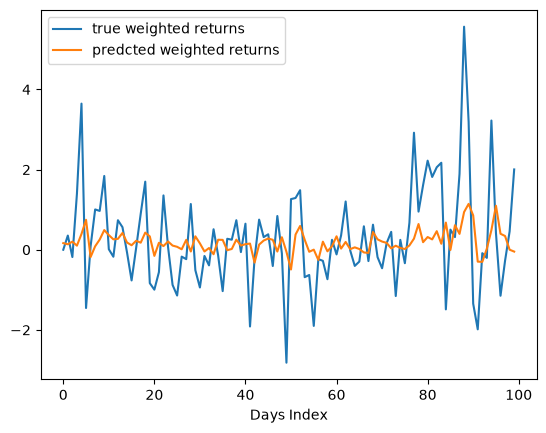

In [10]:
plt.plot(list(fin_data['weighted_sector_returns'][:100]))
plt.plot(pred[:100])
plt.legend(['true weighted returns', 'predcted weighted returns'])
plt.xlabel('Days Index') 
plt.show()

In [11]:
fin_data['weighted_sector_returns'].describe()

count    2263.000000
mean        0.160621
std         1.605039
min       -13.106859
25%        -0.510407
50%         0.058116
75%         0.767203
max         9.392698
Name: weighted_sector_returns, dtype: float64

In [13]:
import numpy as np
np.std(pred)

np.float64(0.38891053568138767)

Its still not capturing enough of the variance. LETS RUN A GRID SEARCH

In [17]:
data_array = fin_data['weighted_sector_returns'].to_numpy().reshape(-1, 1)
data_array

array([[ 0.        ],
       [ 0.35343188],
       [-0.18222328],
       ...,
       [ 0.77979905],
       [ 1.50589331],
       [ 1.53602149]], shape=(2263, 1))

In [18]:
data_array.ndim

2

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = fin_data['weighted_sector_returns'].to_numpy().reshape(-1, 1) # to get a 2d numpy array

avg_errors = []

for p in [1,9,18,34]:
    for q in [1,2,4,10]:
        errors = []
        tscv = TimeSeriesSplit(test_size=10)

        for train_index, test_index in tscv.split(data_array):
            X_train = data_array[train_index]
            X_test = data_array[test_index]
            X_test_orig = X_test.copy()
            fcst = []

            for step in range(10):
                try:
                    mod = ARIMA(X_train, order=(p, 0, q))
                    res = mod.fit()

                    # Convert forecast from array to scalar
                    forecast = res.forecast(steps=1)[0]
                    fcst.append(forecast)

                except Exception as e:
                    print(f"Error for p={p}, q={q}, step={step}: {e}")

                    # Use a scalar here as well
                    fcst.append(np.nan)

                # Add actual observation to training data
                X_train = np.concatenate(
                    (X_train, X_test[0:1, :])
                )

                # Remove first test observation
                X_test = X_test[1:] ## so that by the next iteration it does not repeat the same datapoint sent to x_train

            # Convert actual values to 1D
            y_true = X_test_orig.ravel()

            # Convert forecasts to 1D
            y_pred = np.array(fcst)

            # Don't calculate R² if a model failed
            if np.isnan(y_pred).any():
                errors.append(np.nan)
            else:
                errors.append(r2_score(y_true, y_pred))

        pq_result = [p, q, np.nanmean(errors)]
        print(pq_result)
        avg_errors.append(pq_result)

[1, 1, np.float64(-0.14497095260133255)]
[1, 2, np.float64(-0.14793224940773253)]
[1, 4, np.float64(-0.14853324239400362)]
[1, 10, np.float64(-0.15531429096155952)]
[1, 20, np.float64(-0.15527898557786057)]


KeyboardInterrupt: 

This training is too slow! We need to move on from this o ARIMA